In [29]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
app_df = pd.read_csv("application_record.csv")
print(app_df.head())


        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Rented apartment      -12005 

In [31]:
# See column names, data types, and missing values
app_df.info()

# Get a quick statistical summary of your risk 
app_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [32]:
# Rename specific columns for better readability
app_df.rename(columns={
    'CODE_GENDER': 'GENDER',
    'FLAG_OWN_CAR': 'OWNS_CAR',
    'FLAG_OWN_REALTY': 'OWNS_PROPERTY',
    'CNT_CHILDREN': 'CHILDREN_COUNT',
    'AMT_INCOME_TOTAL': 'ANNUAL_INCOME',
    'NAME_INCOME_TYPE': 'INCOME_CATEGORY',
    'NAME_EDUCATION_TYPE': 'EDUCATION_LEVEL',
    'NAME_FAMILY_STATUS': 'MARITAL_STATUS',
    'NAME_HOUSING_TYPE': 'HOUSING_TYPE',
    'DAYS_BIRTH': 'AGE_IN_DAYS',
    'DAYS_EMPLOYED': 'EMPLOYMENT_DURATION_DAYS',
    'OCCUPATION_TYPE': 'OCCUPATION',
    'CNT_FAM_MEMBERS': 'FAMILY_SIZE',
    'FLAG_PHONE': 'PHONE',
    'FLAG_EMAIL': 'EMAIL'
}, inplace=True)

# Verify the changes
print(app_df.columns)


Index(['ID', 'GENDER', 'OWNS_CAR', 'OWNS_PROPERTY', 'CHILDREN_COUNT',
       'ANNUAL_INCOME', 'INCOME_CATEGORY', 'EDUCATION_LEVEL', 'MARITAL_STATUS',
       'HOUSING_TYPE', 'AGE_IN_DAYS', 'EMPLOYMENT_DURATION_DAYS', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'PHONE', 'EMAIL', 'OCCUPATION', 'FAMILY_SIZE'],
      dtype='object')


In [33]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [34]:
import numpy as np

# 1. Convert Age to positive years
app_df['AGE'] = (app_df['AGE_IN_DAYS'] / -365).astype(int)

# 2. Handle the '365243' flag in Employment
# We replace the flag with 0 (unemployed) and then convert to years
app_df['EMPLOYEMENT_YEARS'] = app_df['EMPLOYMENT_DURATION_DAYS'].replace(365243, 0)
app_df['EMPLOYEMENT_YEARS'] = (app_df['EMPLOYMENT_DURATION_DAYS'] / -365)

# 3. Clean up: Drop the old confusing columns
app_df.drop(columns=['AGE_IN_DAYS', 'EMPLOYMENT_DURATION_DAYS', 'FLAG_MOBIL', 'FLAG_WORK_PHONE'], inplace=True)
# Round to 1 decimal place
app_df['EMPLOYEMENT_YEARS'] = app_df['EMPLOYEMENT_YEARS'].round(1)

# Check the results
print(app_df.head())


        ID GENDER OWNS_CAR OWNS_PROPERTY  CHILDREN_COUNT  ANNUAL_INCOME  \
0  5008804      M        Y             Y               0       427500.0   
1  5008805      M        Y             Y               0       427500.0   
2  5008806      M        Y             Y               0       112500.0   
3  5008808      F        N             Y               0       270000.0   
4  5008809      F        N             Y               0       270000.0   

        INCOME_CATEGORY                EDUCATION_LEVEL        MARITAL_STATUS  \
0               Working               Higher education        Civil marriage   
1               Working               Higher education        Civil marriage   
2               Working  Secondary / secondary special               Married   
3  Commercial associate  Secondary / secondary special  Single / not married   
4  Commercial associate  Secondary / secondary special  Single / not married   

        HOUSING_TYPE  PHONE  EMAIL      OCCUPATION  FAMILY_SIZE  AGE

In [35]:
#Identify missing data
app_df.isnull().sum()

ID                        0
GENDER                    0
OWNS_CAR                  0
OWNS_PROPERTY             0
CHILDREN_COUNT            0
ANNUAL_INCOME             0
INCOME_CATEGORY           0
EDUCATION_LEVEL           0
MARITAL_STATUS            0
HOUSING_TYPE              0
PHONE                     0
EMAIL                     0
OCCUPATION           134203
FAMILY_SIZE               0
AGE                       0
EMPLOYEMENT_YEARS         0
dtype: int64

In [36]:
# Fill nulls with 'Unknown'
app_df['OCCUPATION'] = app_df['OCCUPATION'].fillna('Unknown')
print(app_df['OCCUPATION'].value_counts())



OCCUPATION
Unknown                  134203
Laborers                  78240
Core staff                43007
Sales staff               41098
Managers                  35487
Drivers                   26090
High skill tech staff     17289
Accountants               15985
Medicine staff            13520
Cooking staff              8076
Security staff             7993
Cleaning staff             5845
Private service staff      3456
Low-skill Laborers         2140
Secretaries                2044
Waiters/barmen staff       1665
Realty agents              1041
HR staff                    774
IT staff                    604
Name: count, dtype: int64


In [37]:
# Check what 'income_category' the Unknown occupations have
print(app_df[app_df['OCCUPATION'] == 'Unknown']['INCOME_CATEGORY'].value_counts())


INCOME_CATEGORY
Pensioner               75357
Working                 35886
Commercial associate    16745
State servant            6210
Student                     5
Name: count, dtype: int64


In [38]:

# Compare average income across your new occupation groups
print(app_df.groupby('OCCUPATION')['ANNUAL_INCOME'].mean().sort_values(ascending=False))

# This formats the display for the top 5 rows
app_df.head().style.format({'ANNUAL_INCOME': '${:,.2f}'})


OCCUPATION
Managers                 282125.938701
Realty agents            223510.806916
Accountants              215137.274977
IT staff                 210958.733444
HR staff                 203620.686047
Drivers                  202065.242047
Private service staff    201600.651042
High skill tech staff    195712.011010
Core staff               190905.844378
Laborers                 179865.810449
Sales staff              170912.759267
Unknown                  170869.803331
Security staff           169835.113662
Secretaries              169456.878669
Medicine staff           168102.197707
Waiters/barmen staff     158796.621622
Cooking staff            155848.425334
Low-skill Laborers       150334.309346
Cleaning staff           147064.463815
Name: ANNUAL_INCOME, dtype: float64


,ID,GENDER,OWNS_CAR,OWNS_PROPERTY,CHILDREN_COUNT,ANNUAL_INCOME,INCOME_CATEGORY,EDUCATION_LEVEL,MARITAL_STATUS,HOUSING_TYPE,PHONE,EMAIL,OCCUPATION,FAMILY_SIZE,AGE,EMPLOYEMENT_YEARS
0,5008804,M,Y,Y,0,"$427,500.00",Working,Higher education,Civil marriage,Rented apartment,0,0,Unknown,2.000000,32,12.400000
1,5008805,M,Y,Y,0,"$427,500.00",Working,Higher education,Civil marriage,Rented apartment,0,0,Unknown,2.000000,32,12.400000
2,5008806,M,Y,Y,0,"$112,500.00",Working,Secondary / secondary special,Married,House / apartment,0,0,Security staff,2.000000,58,3.100000
3,5008808,F,N,Y,0,"$270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,1,Sales staff,1.000000,52,8.400000
4,5008809,F,N,Y,0,"$270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,1,Sales staff,1.000000,52,8.400000


In [39]:
app_df.duplicated().sum()

np.int64(0)

In [40]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [42]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [43]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest

# --- 2. STATISTICAL CHECKS ---

# IQR Method
Q1 = app_df['ANNUAL_INCOME'].quantile(0.25)
Q3 = app_df['ANNUAL_INCOME'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = app_df[(app_df['ANNUAL_INCOME'] < lower_iqr) | (app_df['ANNUAL_INCOME'] > upper_iqr)]

# --- 4. PRINT RESULTS ---
print(f"Total Rows: {len(app_df)}")
print(f"Outliers detected by IQR: {len(outliers_iqr)}")




Total Rows: 438557
Outliers detected by IQR: 19108


Total Rows: 438557
Outliers detected by IQR: 19108
Outliers detected by Z-Score: 5276
Outliers detected by Isolation Forest: 21925


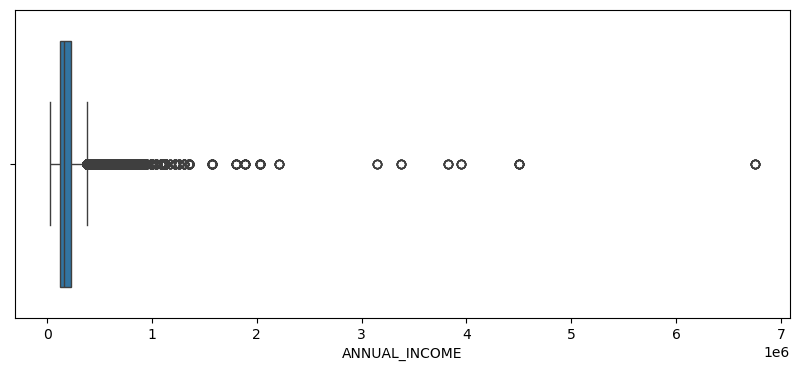

In [45]:

# Z-Score Method
"""z_scores = np.abs(stats.zscore(app_df['ANNUAL_INCOME'].dropna())) # dropna handles missing values
outliers_z = app_df.iloc[z_scores[z_scores > 3].index]

# --- 3. MACHINE LEARNING CHECK ---

# Isolation Forest
# contamination=0.05 assumes 5% of your data might be outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
preds = iso_forest.fit_predict(app_df[['ANNUAL_INCOME']].dropna())
outliers_iso = app_df.iloc[np.where(preds == -1)[0]]

# --- 4. PRINT RESULTS ---
print(f"Total Rows: {len(app_df)}")
print(f"Outliers detected by IQR: {len(outliers_iqr)}")
print(f"Outliers detected by Z-Score: {len(outliers_z)}")
print(f"Outliers detected by Isolation Forest: {len(outliers_iso)}")

# --- 5. VISUALIZE ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=app_df['ANNUAL_INCOME'])
#plt.title(f'Outlier Visualization for {'ANNUAL_INCOME'}')
#plt.show()"""
# Z-Score Method
valid_indices = app_df['ANNUAL_INCOME'].dropna().index
z_scores = np.abs(stats.zscore(app_df['ANNUAL_INCOME'].dropna())) # dropna handles missing values
outliers_z = app_df.loc[valid_indices[z_scores > 3]]

# --- 3. MACHINE LEARNING CHECK ---

# Isolation Forest
# contamination=0.05 assumes 5% of your data might be outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
preds = iso_forest.fit_predict(app_df[['ANNUAL_INCOME']].dropna())
outliers_iso = app_df.iloc[np.where(preds == -1)[0]]

# --- 4. PRINT RESULTS ---
print(f"Total Rows: {len(app_df)}")
print(f"Outliers detected by IQR: {len(outliers_iqr)}")
print(f"Outliers detected by Z-Score: {len(outliers_z)}")
print(f"Outliers detected by Isolation Forest: {len(outliers_iso)}")

# --- 5. VISUALIZE ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=app_df['ANNUAL_INCOME'])
#plt.title(f'Outlier Visualization for {'ANNUAL_INCOME'}')
plt.show()

In [46]:
credit_df=pd.read_csv("credit_record.csv")
print(credit_df.head())

        ID  MONTHS_BALANCE STATUS
0  5001711               0      X
1  5001711              -1      0
2  5001711              -2      0
3  5001711              -3      0
4  5001712               0      C


In [47]:
# (Simplified: Treat anything > 60 days past due as '1/Bad')
credit_df['TARGET'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['2','3','4','5'] else 0)
print(credit_df.head())

        ID  MONTHS_BALANCE STATUS  TARGET
0  5001711               0      X       0
1  5001711              -1      0       0
2  5001711              -2      0       0
3  5001711              -3      0       0
4  5001712               0      C       0


In [48]:
credit_df['MONTHS_BALANCE'] = credit_df['MONTHS_BALANCE'].abs()
print(credit_df.head(50))

         ID  MONTHS_BALANCE STATUS  TARGET
0   5001711               0      X       0
1   5001711               1      0       0
2   5001711               2      0       0
3   5001711               3      0       0
4   5001712               0      C       0
5   5001712               1      C       0
6   5001712               2      C       0
7   5001712               3      C       0
8   5001712               4      C       0
9   5001712               5      C       0
10  5001712               6      C       0
11  5001712               7      C       0
12  5001712               8      C       0
13  5001712               9      0       0
14  5001712              10      0       0
15  5001712              11      0       0
16  5001712              12      0       0
17  5001712              13      0       0
18  5001712              14      0       0
19  5001712              15      0       0
20  5001712              16      0       0
21  5001712              17      0       0
22  5001712

In [49]:
# Let's assume: 1 = Bad (Late/Default), 0 = Good (On time/Closed)
credit_df['IS_BAD_DEBT'] = credit_df['STATUS'].apply(lambda x: 1 if x in ['2', '3', '4', '5'] else 0)

# Collapse the ID redundancy
# We use 'max' for the status to catch if they were EVER 'Bad'
# We use 'count' for MONTHS_BALANCE to see how long their history is
credit_pivot = credit_df.groupby('ID').agg(
    TOTAL_MONTHS_TRACKED=('MONTHS_BALANCE', 'count'),
    HAS_DEFAULTED=('IS_BAD_DEBT', 'max'),        # If max is 1, they defaulted at least once
    AVERAGE_MONTHLY_RISK=('IS_BAD_DEBT', 'mean')  # Shows the frequency of bad months
).reset_index()

# 3. Clean up the Months Balance (as you requested earlier)
# To get the account age, we take the max of the positive version of months
credit_pivot['ACCOUNT_AGE_MONTHS'] = credit_df.groupby('ID')['MONTHS_BALANCE'].max().abs().values

print(f"Original rows: {len(credit_df)}")
print(f"Unique Customers: {len(credit_pivot)}")


Original rows: 1048575
Unique Customers: 45985


In [50]:
# Display the first 10 unique customers and their risk metrics
print(credit_pivot[['ID', 'TOTAL_MONTHS_TRACKED', 'AVERAGE_MONTHLY_RISK']].head(10))

# Get a statistical summary of these two new metrics
print(credit_pivot[['TOTAL_MONTHS_TRACKED', 'AVERAGE_MONTHLY_RISK']].describe())


        ID  TOTAL_MONTHS_TRACKED  AVERAGE_MONTHLY_RISK
0  5001711                     4                   0.0
1  5001712                    19                   0.0
2  5001713                    22                   0.0
3  5001714                    15                   0.0
4  5001715                    60                   0.0
5  5001717                    22                   0.0
6  5001718                    39                   0.0
7  5001719                    43                   0.0
8  5001720                    36                   0.0
9  5001723                    31                   0.0
       TOTAL_MONTHS_TRACKED  AVERAGE_MONTHLY_RISK
count          45985.000000          45985.000000
mean              22.802544              0.002310
std               15.492771              0.030421
min                1.000000              0.000000
25%               10.000000              0.000000
50%               19.000000              0.000000
75%               34.000000              0.00

In [51]:
credit_df.describe()

,ID,MONTHS_BALANCE,TARGET,IS_BAD_DEBT
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.068286e+06,1.913700e+01,2.960208e-03,2.960208e-03
std,4.615058e+04,1.402350e+01,5.432723e-02,5.432723e-02
min,5.001711e+06,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.023644e+06,7.000000e+00,0.000000e+00,0.000000e+00
50%,5.062104e+06,1.700000e+01,0.000000e+00,0.000000e+00
75%,5.113856e+06,2.900000e+01,0.000000e+00,0.000000e+00
max,5.150487e+06,6.000000e+01,1.000000e+00,1.000000e+00


In [52]:
credit_pivot.describe()

,ID,TOTAL_MONTHS_TRACKED,HAS_DEFAULTED,AVERAGE_MONTHLY_RISK,ACCOUNT_AGE_MONTHS
count,4.598500e+04,45985.000000,45985.000000,45985.000000,45985.000000
mean,5.070164e+06,22.802544,0.014505,0.002310,26.433489
std,4.543364e+04,15.492771,0.119560,0.030421,16.481280
min,5.001711e+06,1.000000,0.000000,0.000000,0.000000
25%,5.026147e+06,10.000000,0.000000,0.000000,12.000000
50%,5.065737e+06,19.000000,0.000000,0.000000,25.000000
75%,5.114024e+06,34.000000,0.000000,0.000000,40.000000
max,5.150487e+06,61.000000,1.000000,0.951220,60.000000


In [53]:
# Drop redundant columns from credit pivot
credit_pivot_records= credit_pivot.drop(columns=['Target', 'TARGET'], errors='ignore')

# Inner Merge: Keeps only IDs present in both files
merged_df= pd.merge(app_df, credit_pivot_records, on='ID', how='inner')

print(f"Final EDA Dataset Shape: {merged_df.shape}")
merged_df.head()


Final EDA Dataset Shape: (36457, 20)


,ID,GENDER,OWNS_CAR,OWNS_PROPERTY,CHILDREN_COUNT,ANNUAL_INCOME,INCOME_CATEGORY,EDUCATION_LEVEL,MARITAL_STATUS,HOUSING_TYPE,PHONE,EMAIL,OCCUPATION,FAMILY_SIZE,AGE,EMPLOYEMENT_YEARS,TOTAL_MONTHS_TRACKED,HAS_DEFAULTED,AVERAGE_MONTHLY_RISK,ACCOUNT_AGE_MONTHS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,0,0,Unknown,2.0,32,12.4,16,0,0.0,15
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,0,0,Unknown,2.0,32,12.4,15,0,0.0,14
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,Security staff,2.0,58,3.1,30,0,0.0,29
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,1,Sales staff,1.0,52,8.4,5,0,0.0,4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,1,Sales staff,1.0,52,8.4,5,0,0.0,26


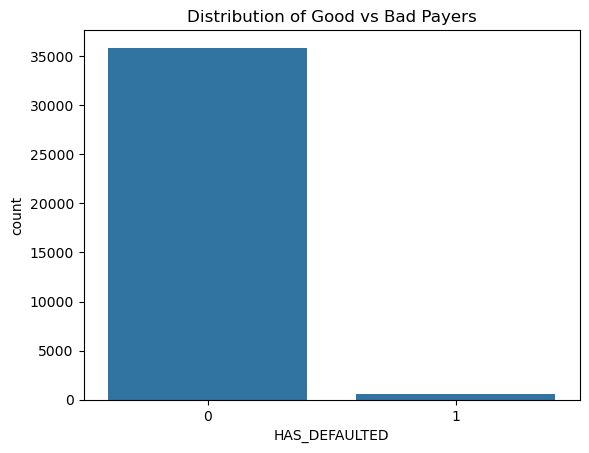

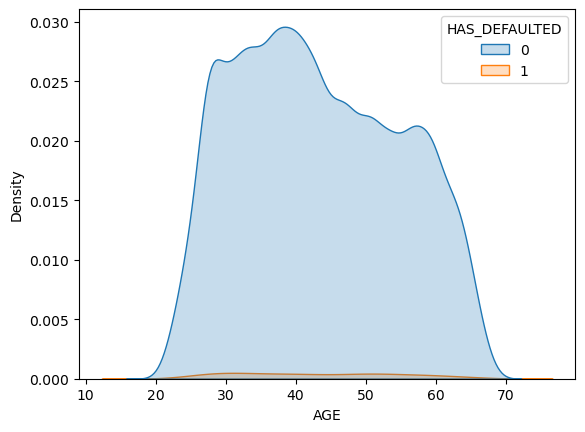

In [54]:
# 1. Target Balance
sns.countplot(x='HAS_DEFAULTED', data=merged_df, fill=True )
plt.title('Distribution of Good vs Bad Payers')
plt.show()

# 2. Age Distribution 
sns.kdeplot(data=merged_df, x='AGE', hue='HAS_DEFAULTED', fill=True)
plt.show()


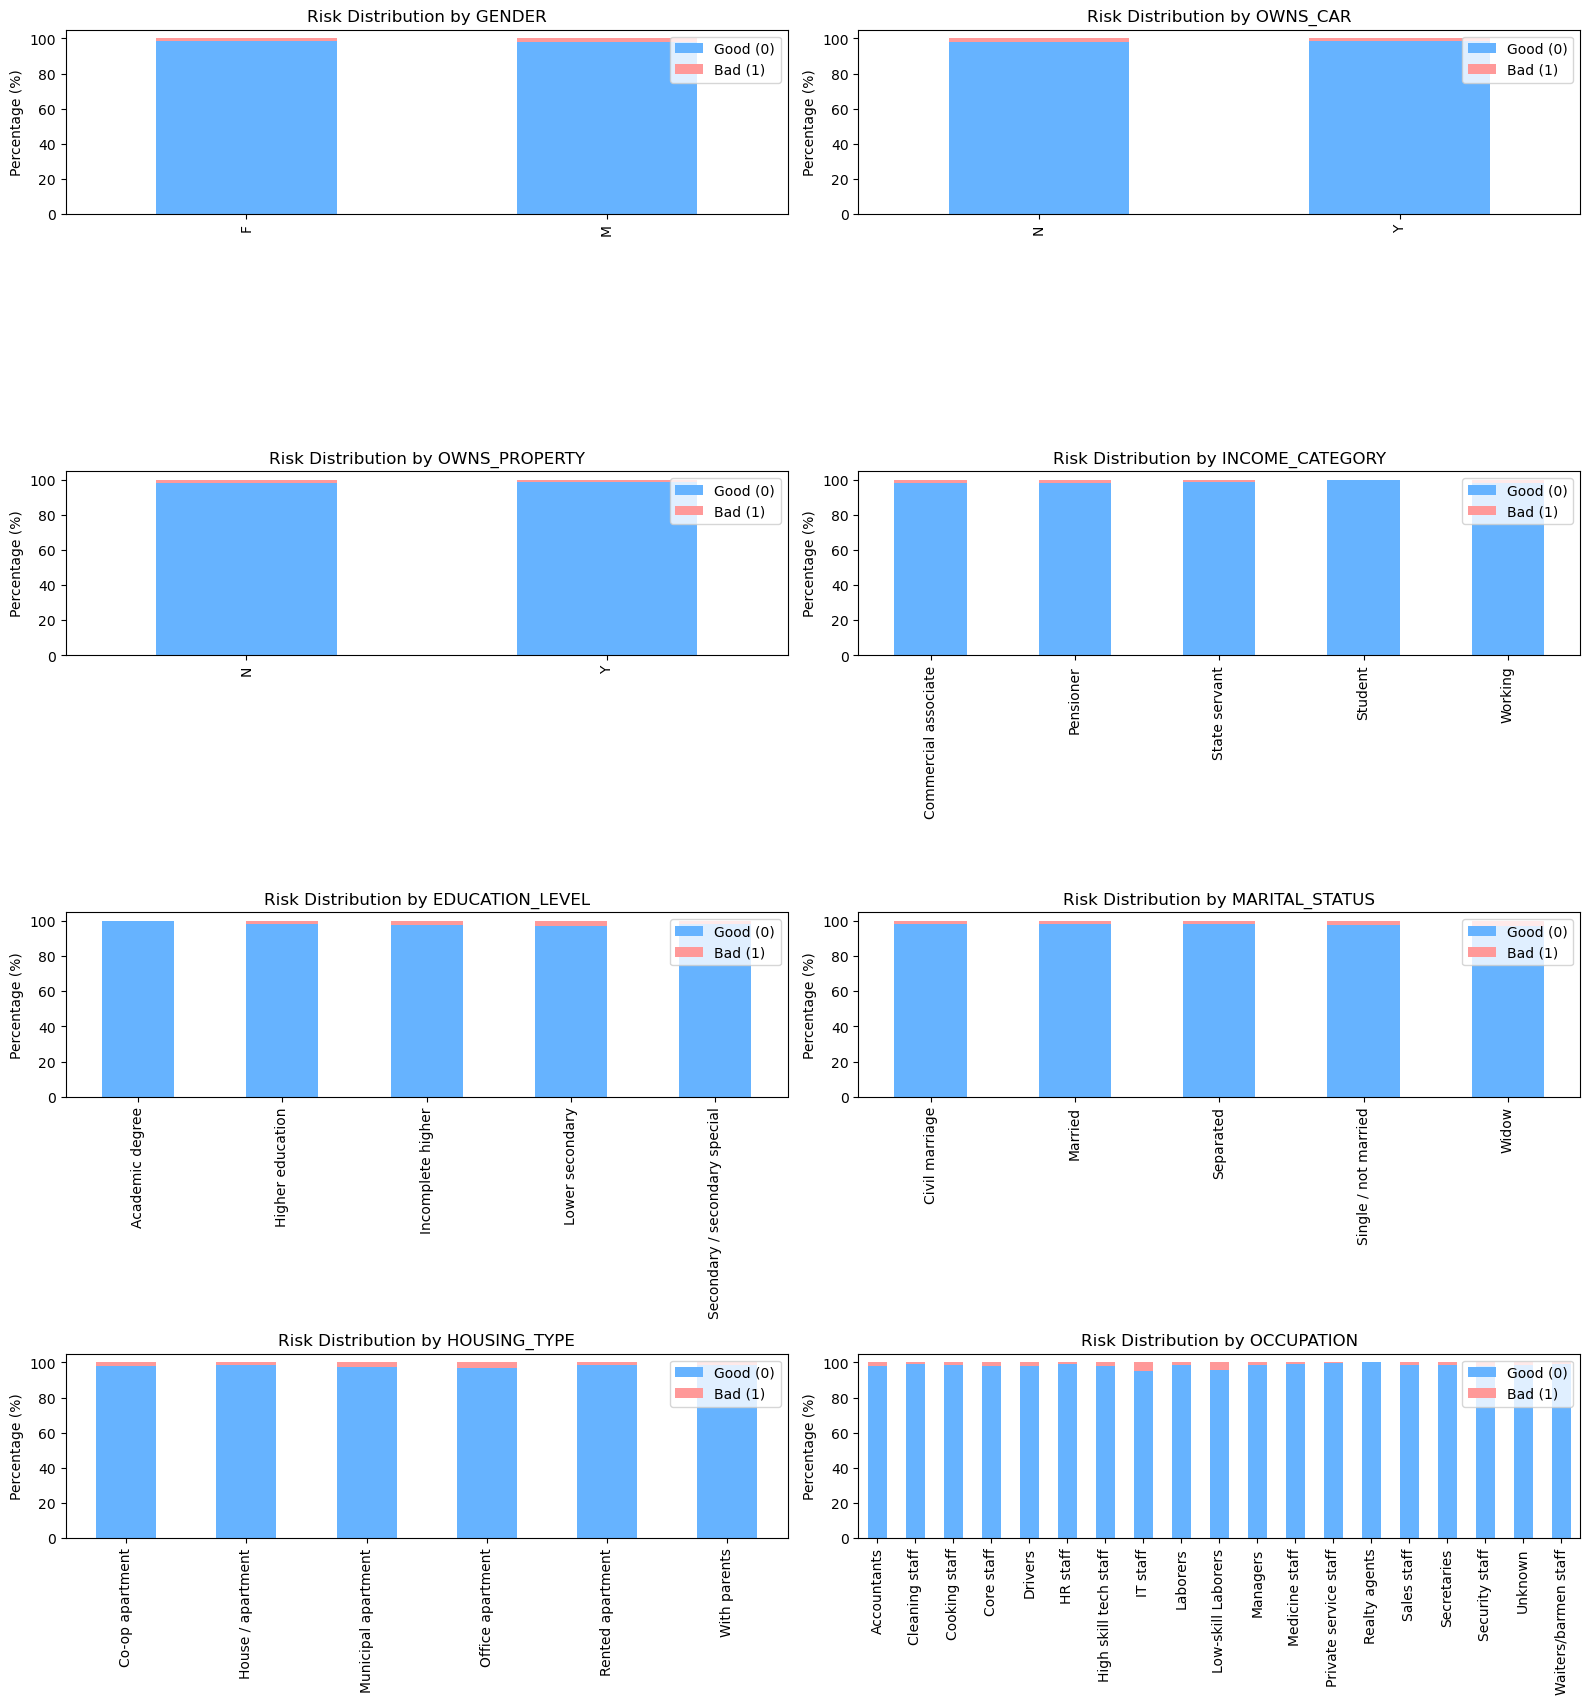

In [55]:
# 1. Identify categorical columns (excluding ID and your Target)
categorical_cols = merged_df.select_dtypes(include=['object']).columns.tolist()

# 2. Set up the figure grid
plt.figure(figsize=(16, 20))
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols)//2 + 1, 2, i + 1)
    
    # Create a cross-tabulation to show percentages
    # This helps see which category has a HIGHER RATE of bad payers
    plot_data = pd.crosstab(merged_df[col], merged_df['HAS_DEFAULTED'], normalize='index') * 100
    
    plot_data.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#66b3ff','#ff9999'])
    
    plt.title(f'Risk Distribution by {col}')
    plt.ylabel('Percentage (%)')
    plt.xlabel('')
    plt.legend(['Good (0)', 'Bad (1)'], loc='upper right')

plt.tight_layout()
plt.show()


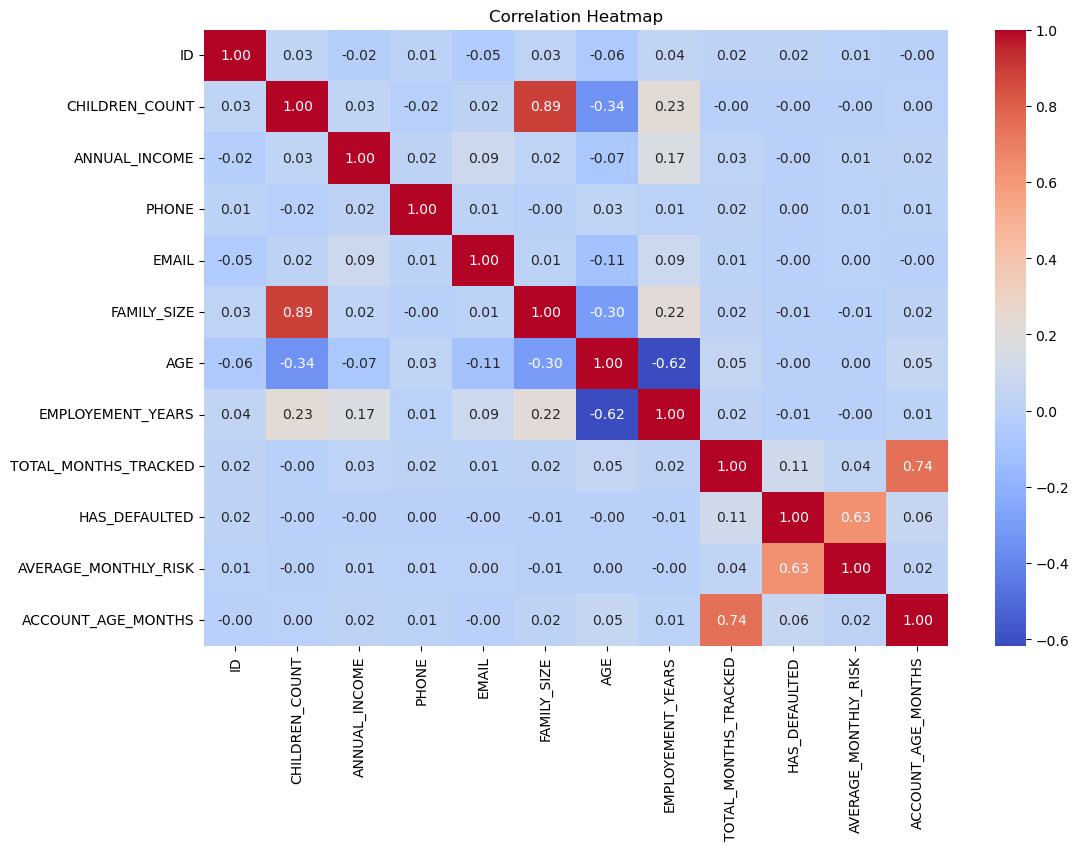

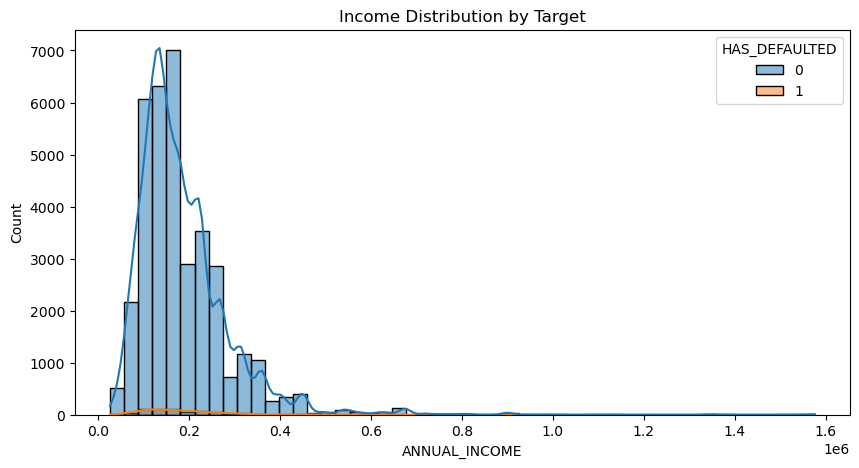

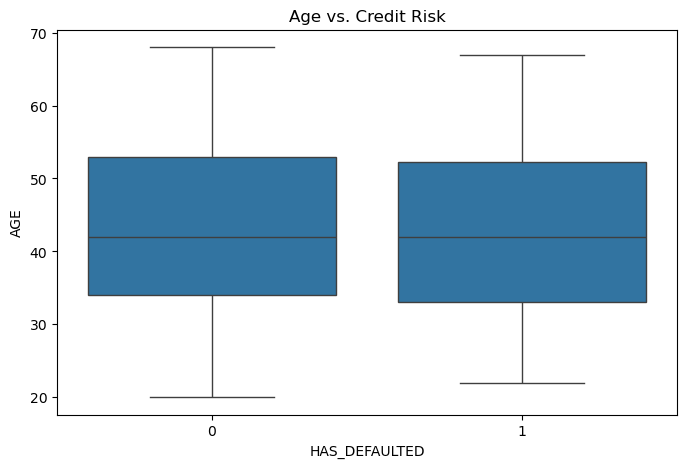

In [56]:
# 1. Heatmap to see feature importance and redundancy
plt.figure(figsize=(12, 8))

# Use the numeric_only=True parameter
sns.heatmap(merged_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

#sns.heatmap(merged_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# 2. Histogram for Income (Log Scale often helps here)
plt.figure(figsize=(10, 5))
sns.histplot(data=merged_df, x='ANNUAL_INCOME', hue='HAS_DEFAULTED', kde=True, bins=50)
plt.title("Income Distribution by Target")
plt.show()

# 3. Boxplot for Age 
plt.figure(figsize=(8, 5))
sns.boxplot(x='HAS_DEFAULTED', y='AGE', data=merged_df)
plt.title("Age vs. Credit Risk")
plt.show()


# SECTION 3: FEATURE ENGINEERING
## Create additional predictive features to improve model performance

# SECTION 4: FEATURE SELECTION
## Select the best features to reduce dimensionality and improve model efficiency

# SECTION 5: DATA PREPROCESSING
## Encode categorical variables and scale numerical features

In [57]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Prepare final dataset with selected features
X_selected = df_encoded[best_features].fillna(0)
y = df_encoded['HAS_DEFAULTED']

# Identify numeric and categorical columns in selected features
numeric_features_selected = [col for col in best_features if col in numeric_cols or col in X_selected.select_dtypes(include=[np.number]).columns.tolist()]
categorical_features_selected = [col for col in best_features if col in categorical_cols]

print(f"Numeric features: {numeric_features_selected}")
print(f"Categorical features: {categorical_features_selected}")

# Scale numeric features
scaler = StandardScaler()
X_scaled = X_selected.copy()

if numeric_features_selected:
    X_scaled[numeric_features_selected] = scaler.fit_transform(X_selected[numeric_features_selected])

# Check for any remaining null values
print(f"\nNull values after preprocessing:")
print(X_scaled.isnull().sum())

# Fill any remaining nulls with 0
X_scaled = X_scaled.fillna(0)

print(f"\nPreprocessed data shape: {X_scaled.shape}")
print(f"Features: {X_scaled.columns.tolist()}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True)}")

NameError: name 'df_encoded' is not defined

# SECTION 6: TRAIN/TEST SPLIT
## Divide data into training and validation sets

In [ ]:
# Split data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintains class distribution
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

# SECTION 7: MODEL BUILDING
## Train multiple classification models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Dictionary to store trained models
models = {}

# 1. Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
models['Logistic Regression'] = lr_model
print("✓ Logistic Regression trained")

# 2. Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
print("✓ Random Forest trained")

# 3. Gradient Boosting
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
models['Gradient Boosting'] = gb_model
print("✓ Gradient Boosting trained")

# 4. XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
print("✓ XGBoost trained")

print("\nAll models trained successfully!")
print(f"Total models trained: {len(models)}")

# SECTION 8: MODEL EVALUATION
## Evaluate model performance using multiple metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate all models
results = []

for model_name, model in models.items():
    # Training set predictions
    y_train_pred = model.predict(X_train)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, 'predict_proba') else y_train_pred
    
    # Test set predictions
    y_test_pred = model.predict(X_test)
    y_test_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_test_pred
    
    # Calculate metrics
    results.append({
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc_score(y_test, y_test_pred_proba)
    })
    
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba):.4f}\n")
    print(classification_report(y_test, y_test_pred))

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

In [ ]:
# Visualization: ROC Curves for all models
plt.figure(figsize=(12, 8))

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Feature importance for tree-based models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Random Forest Feature Importance
rf_importances = rf_model.feature_importances_
rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False).head(10)

axes[0, 0].barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'])
axes[0, 0].set_title('Random Forest - Top 10 Features')
axes[0, 0].invert_yaxis()

# Gradient Boosting Feature Importance
gb_importances = gb_model.feature_importances_
gb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_importances
}).sort_values('Importance', ascending=False).head(10)

axes[0, 1].barh(gb_feature_importance['Feature'], gb_feature_importance['Importance'], color='orange')
axes[0, 1].set_title('Gradient Boosting - Top 10 Features')
axes[0, 1].invert_yaxis()

# XGBoost Feature Importance
xgb_importances = xgb_model.feature_importances_
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False).head(10)

axes[1, 0].barh(xgb_feature_importance['Feature'], xgb_feature_importance['Importance'], color='green')
axes[1, 0].set_title('XGBoost - Top 10 Features')
axes[1, 0].invert_yaxis()

# Model Comparison Bar Chart
axes[1, 1].bar(results_df['Model'], results_df['ROC-AUC'], color=['blue', 'orange', 'green', 'red'])
axes[1, 1].set_title('Model Performance - ROC-AUC Score')
axes[1, 1].set_ylabel('ROC-AUC Score')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# SECTION 9: HYPERPARAMETER TUNING
## Optimize model performance using GridSearchCV and RandomizedSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time

# Hyperparameter tuning for top performers (Random Forest, XGBoost)
print("Starting Hyperparameter Tuning...\n")

# 1. Random Forest Tuning
print("="*60)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("="*60)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Running GridSearchCV for Random Forest (this may take a few minutes)...")
start_time = time.time()
rf_grid_search.fit(X_train, y_train)
end_time = time.time()

print(f"Best Random Forest Parameters: {rf_grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {rf_grid_search.best_score_:.4f}")
print(f"Time taken: {(end_time - start_time)/60:.2f} minutes\n")

# Evaluate best RF model
best_rf = rf_grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]
print(f"Best Random Forest Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best_rf):.4f}\n")

# 2. XGBoost Tuning
print("="*60)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*60)

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, verbosity=0),
    xgb_params,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

print("Running RandomizedSearchCV for XGBoost...")
start_time = time.time()
xgb_random_search.fit(X_train, y_train)
end_time = time.time()

print(f"Best XGBoost Parameters: {xgb_random_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {xgb_random_search.best_score_:.4f}")
print(f"Time taken: {(end_time - start_time)/60:.2f} minutes\n")

# Evaluate best XGB model
best_xgb = xgb_random_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
y_pred_proba_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
print(f"Best XGBoost Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best_xgb):.4f}\n")

# SECTION 10: FINAL RESULTS & COMPARISON
## Compare original and tuned models

In [ ]:
# Final comparison of all models
final_results = []

# Original models
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    final_results.append({
        'Model': f'{model_name} (Original)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    })

# Tuned models
y_pred_tuned_rf = best_rf.predict(X_test)
y_pred_proba_tuned_rf = best_rf.predict_proba(X_test)[:, 1]
final_results.append({
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned_rf),
    'Precision': precision_score(y_test, y_pred_tuned_rf),
    'Recall': recall_score(y_test, y_pred_tuned_rf),
    'F1-Score': f1_score(y_test, y_pred_tuned_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_tuned_rf)
})

y_pred_tuned_xgb = best_xgb.predict(X_test)
y_pred_proba_tuned_xgb = best_xgb.predict_proba(X_test)[:, 1]
final_results.append({
    'Model': 'XGBoost (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned_xgb),
    'Precision': precision_score(y_test, y_pred_tuned_xgb),
    'Recall': recall_score(y_test, y_pred_tuned_xgb),
    'F1-Score': f1_score(y_test, y_pred_tuned_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_tuned_xgb)
})

# Create final results dataframe
final_results_df = pd.DataFrame(final_results).sort_values('ROC-AUC', ascending=False)

print("\n" + "="*100)
print("FINAL MODEL COMPARISON - ALL METRICS")
print("="*100)
print(final_results_df.to_string(index=False))

print("\n" + "="*100)
print("BEST MODEL RECOMMENDATION")
print("="*100)
best_model_row = final_results_df.iloc[0]
print(f"\n🏆 Best Model: {best_model_row['Model']}")
print(f"   ROC-AUC Score: {best_model_row['ROC-AUC']:.4f}")
print(f"   Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"   Precision: {best_model_row['Precision']:.4f}")
print(f"   Recall: {best_model_row['Recall']:.4f}")
print(f"   F1-Score: {best_model_row['F1-Score']:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-AUC Comparison
axes[0].barh(final_results_df['Model'], final_results_df['ROC-AUC'], color=['green' if i == 0 else 'skyblue' for i in range(len(final_results_df))])
axes[0].set_xlabel('ROC-AUC Score')
axes[0].set_title('Model Comparison - ROC-AUC Score')
axes[0].set_xlim([0, 1])
for i, v in enumerate(final_results_df['ROC-AUC']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Metrics Radar Plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
top_3_models = final_results_df.head(3)

for idx, row in top_3_models.iterrows():
    values = [row[metric] for metric in metrics]
    axes[1].plot(metrics, values, marker='o', label=row['Model'])

axes[1].set_ylim([0, 1])
axes[1].set_title('Top 3 Models - All Metrics')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# SECTION 11: MODEL PERSISTENCE
## Save the best model for future use

In [ ]:
import pickle
import joblib

# Save the best model and preprocessing objects
best_model_name = final_results_df.iloc[0]['Model']
if 'Tuned' in best_model_name:
    if 'Random Forest' in best_model_name:
        best_model = best_rf
    else:
        best_model = best_xgb
else:
    best_model = models[best_model_name.replace(' (Original)', '')]

# Save model
model_filename = 'credit_risk_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f"✓ Best model saved as '{model_filename}'")

# Save scaler for future predictions
scaler_filename = 'credit_risk_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved as '{scaler_filename}'")

# Save feature list for future predictions
features_filename = 'credit_risk_features.pkl'
joblib.dump(best_features, features_filename)
print(f"✓ Feature list saved as '{features_filename}'")

# Save label encoders for categorical features
le_dict_filename = 'credit_risk_label_encoders.pkl'
joblib.dump(le_dict, le_dict_filename)
print(f"✓ Label encoders saved as '{le_dict_filename}'")

print("\n" + "="*60)
print("MODEL DEPLOYMENT READY")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"ROC-AUC Score: {final_results_df.iloc[0]['ROC-AUC']:.4f}")
print(f"\nFiles saved for deployment:")
print(f"  1. {model_filename}")
print(f"  2. {scaler_filename}")
print(f"  3. {features_filename}")
print(f"  4. {le_dict_filename}")
print("\nTo use the model for new predictions:")
print("  1. Load the model: model = joblib.load('credit_risk_best_model.pkl')")
print("  2. Load the scaler: scaler = joblib.load('credit_risk_scaler.pkl')")
print("  3. Load the features: features = joblib.load('credit_risk_features.pkl')")
print("  4. Make predictions: y_pred = model.predict(X_new_scaled)")